In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Наложение и удаление шума

In [34]:
orig_img = cv2.imread('sar_1.jpg')
gray_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2GRAY)

In [35]:
#Гаусс 130
gauss_noise = np.random.normal(loc=0, scale=130, size=gray_img.shape)
noisy_gauss = np.clip(gray_img.astype(np.float32) + gauss_noise, 0, 255).astype(np.uint8)

#Соль и перец 60%
noisy_sp = gray_img.copy()
noise_ratio = 0.60

#Соль
num_salt = int(noise_ratio * gray_img.size * 0.5)
salt_coords = [np.random.randint(0, i - 1, num_salt) for i in gray_img.shape]
noisy_sp[tuple(salt_coords)] = 255

#Перец
num_pepper = int(noise_ratio * gray_img.size * 0.5)
pepper_coords = [np.random.randint(0, i - 1, num_pepper) for i in gray_img.shape]
noisy_sp[tuple(pepper_coords)] = 0

In [36]:
#Фильтр Гаусса ядро 21x21 и 31x31
gauss_f1 = cv2.GaussianBlur(noisy_gauss, (21, 21), sigmaX=5.0)
gauss_f2 = cv2.GaussianBlur(noisy_gauss, (31, 31), sigmaX=10.0)

#Медианный фильтр окно 9 и 15
median_f1 = cv2.medianBlur(noisy_sp, 9)
median_f2 = cv2.medianBlur(noisy_sp, 15)

#Билатеральный фильтр радиус d и сигма
bilat_f1 = cv2.bilateralFilter(noisy_gauss, d=15, sigmaColor=150, sigmaSpace=150)
bilat_f2 = cv2.bilateralFilter(noisy_gauss, d=25, sigmaColor=250, sigmaSpace=250)

#Фильтр нелокальных средних h=50 и h=80
nlm_f1 = cv2.fastNlMeansDenoising(noisy_gauss, h=50, templateWindowSize=7, searchWindowSize=21)
nlm_f2 = cv2.fastNlMeansDenoising(noisy_gauss, h=80, templateWindowSize=7, searchWindowSize=21)

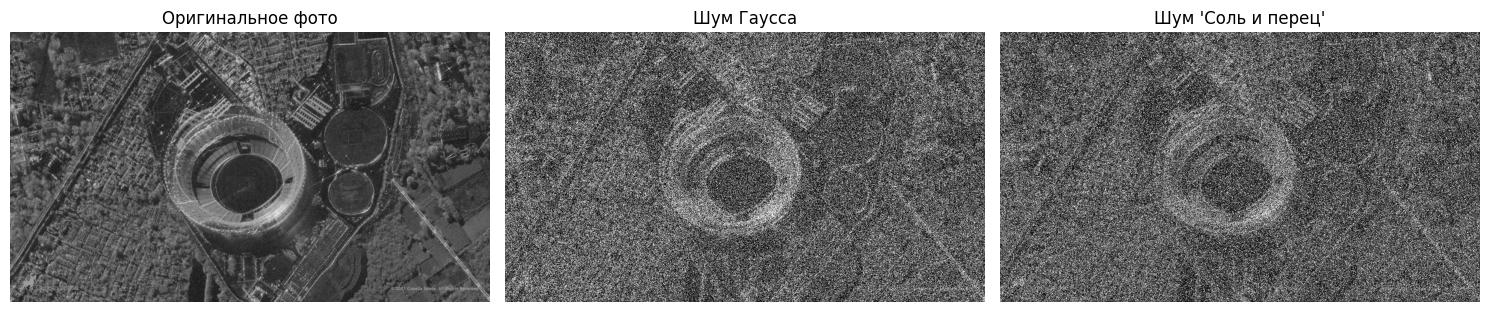

In [37]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.title("Оригинальное фото")
plt.imshow(gray_img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Шум Гаусса")
plt.imshow(noisy_gauss, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Шум 'Соль и перец'")
plt.imshow(noisy_sp, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

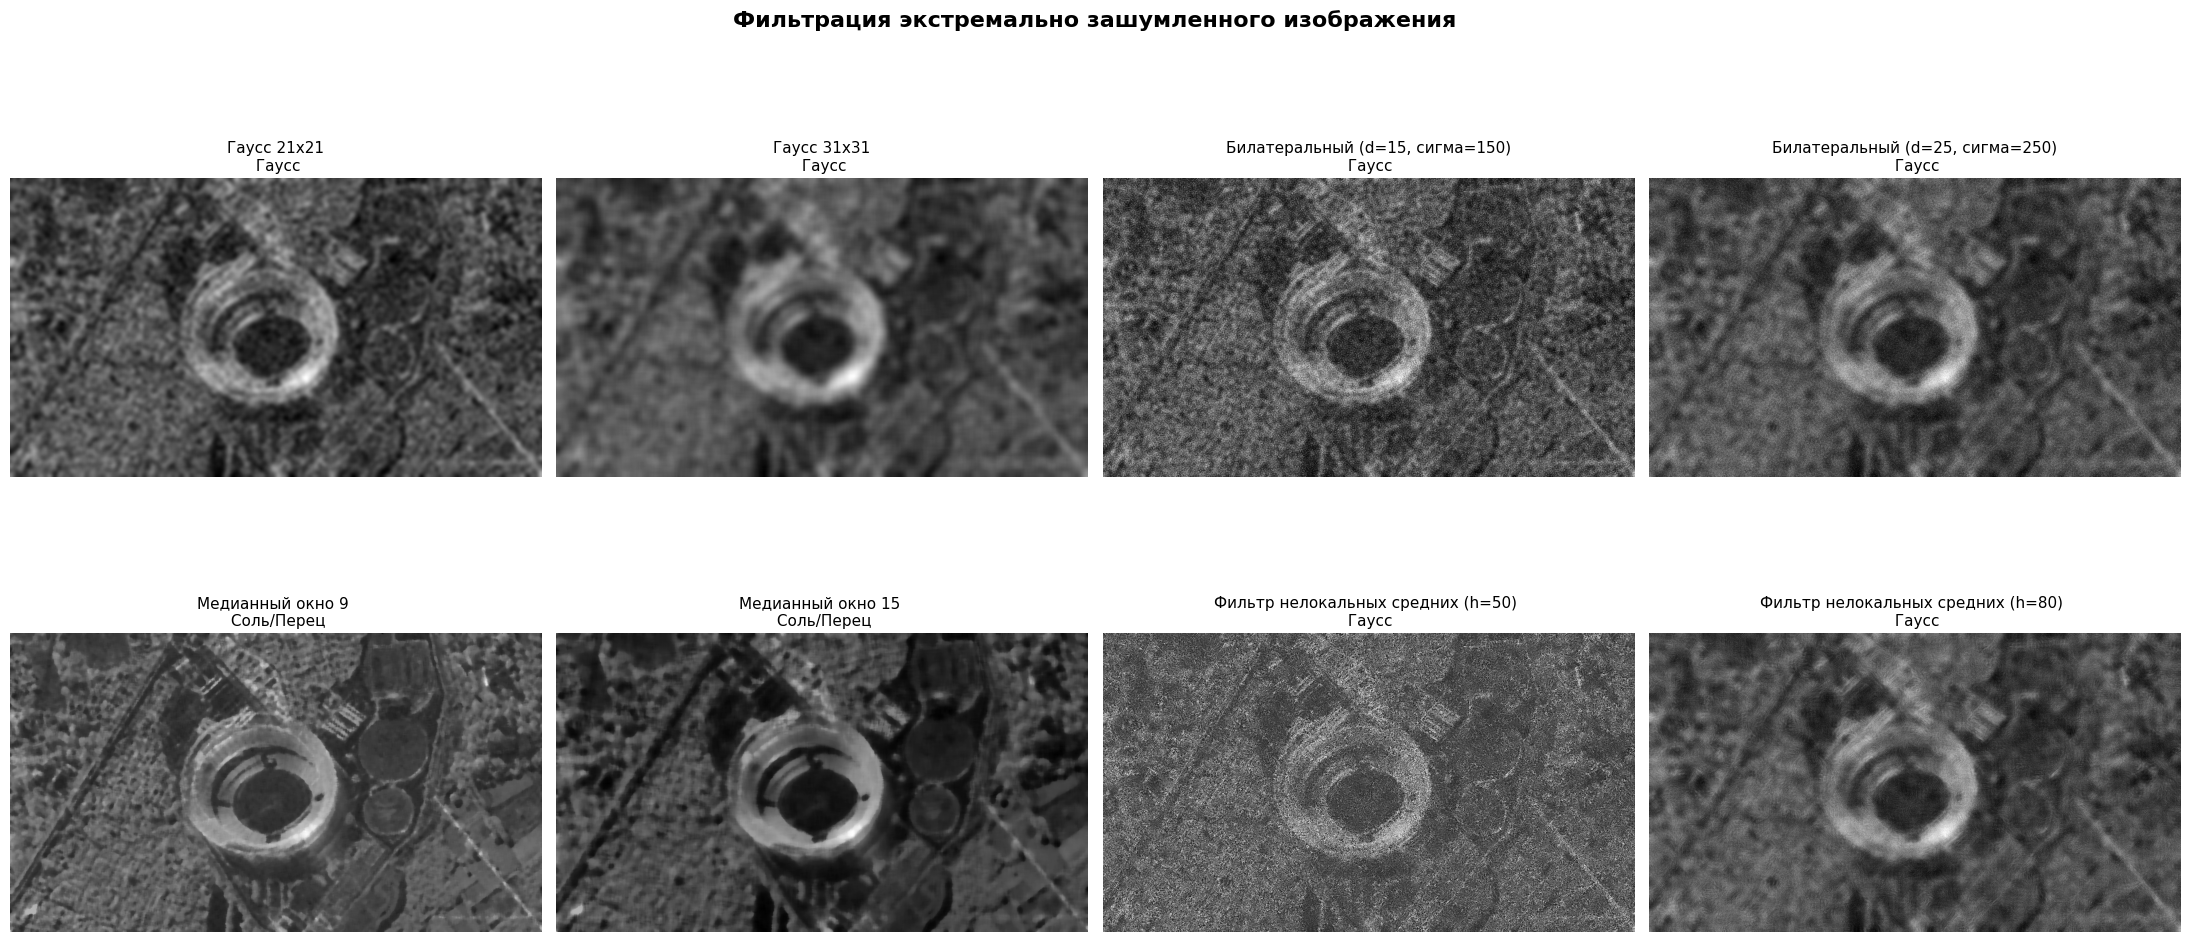

In [38]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.suptitle("Фильтрация экстремально зашумленного изображения", fontsize=16, fontweight='bold')

filter_results = [
    (gauss_f1, "Гаусс 21x21\n Гаусс"),
    (gauss_f2, "Гаусс 31x31\n Гаусс"),
    (bilat_f1, "Билатеральный (d=15, сигма=150)\n Гаусс"),
    (bilat_f2, "Билатеральный (d=25, сигма=250)\n Гаусс"),
    (median_f1, "Медианный окно 9 \n Соль/Перец"),
    (median_f2, "Медианный окно 15 \n Соль/Перец"),
    (nlm_f1, "Фильтр нелокальных средних (h=50) \n Гаусс"),
    (nlm_f2, "Фильтр нелокальных средних (h=80) \n Гаусс")
]

for ax, (img, name) in zip(axes.ravel(), filter_results):
    ax.imshow(img, cmap='gray')
    ax.set_title(name, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [39]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse

print("Оценка фильтрации гаусса")
print(f"NL-Means h=80 -> MSE: {mse(gray_img, nlm_f2):.2f}, SSIM: {ssim(gray_img, nlm_f2):.3f}")
print(f"Билатеральный d=25 -> MSE: {mse(gray_img, bilat_f2):.2f}, SSIM: {ssim(gray_img, bilat_f2):.3f}")

print("\nОценка фильтрации соль и перец")
print(f"Медианный k=9 -> MSE: {mse(gray_img, median_f1):.2f}, SSIM: {ssim(gray_img, median_f1):.3f}")

print("\nВЫВОД:")
print("1. Для шума 'соль и перец' лучшим показал себя медианный фильтр, он полностью удаляет выбросы")
print("2. Для гаусс шума наилучший результат дал фильтр нелокальных средних и билатеральный фильтр, так как они эффективно сглаживают шум, сохраняя четкость границ")

Оценка фильтрации гаусса
NL-Means h=80 -> MSE: 823.35, SSIM: 0.266
Билатеральный d=25 -> MSE: 845.84, SSIM: 0.241

Оценка фильтрации соль и перец
Медианный k=9 -> MSE: 367.96, SSIM: 0.422

ВЫВОД:
1. Для шума 'соль и перец' лучшим показал себя медианный фильтр, он полностью удаляет выбросы
2. Для гаусс шума наилучший результат дал фильтр нелокальных средних и билатеральный фильтр, так как они эффективно сглаживают шум, сохраняя четкость границ


In [40]:
# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.